In [46]:
%matplotlib inline
import numpy as np 
from collections import Counter
from math import log2
import matplotlib.pyplot as plt 

In [47]:
'''
16 hex numbers
'''
def shannon_hex(hid):
    c = Counter(hid)
    score = - sum([(val / 16) * log2(val / 16) for key, val in c.items()])
    return score

In [48]:
'''
64 binary bits, each can take on the value of 0 or 1
'''
def shannon_bin(hid):
    binary = bin(int(hid, 16))[2:].zfill(64)
    c = Counter(binary)
    score = - sum([(val / 64) * log2(val / 64) for key, val in c.items()])
    return score

In [49]:
def plot():
    hex_digs = "0123456789abcdef"
    x = range(len(hex_digs))
    addrs = []
    hex_scores = []
    bin_scores = []
    for i in range(0, 16):
        digs = hex_digs[:i+1]
        addr = digs.zfill(16)
        addrs.append(addr)
        hex_scores.append(shannon_hex(addr))
        bin_scores.append(shannon_bin(addr))

    plt.plot(x, hex_scores, label="hex scores")
    plt.plot(x, bin_scores, label="bin scores")
    plt.legend()
    plt.show()

0000000000000001 -->  0.11611507530476972 binary
                 -->   0.3372900666170139 hex
0000000000001234 -->   0.3955378064564774 binary
                 -->    1.311278124459133 hex
0101010101010101 -->   0.5435644431995964 binary
                 -->                  1.0 hex
0000000011111111 -->   0.5435644431995964 binary
                 -->                  1.0 hex
00000000000021f5 -->   0.5435644431995964 binary
                 -->    1.311278124459133 hex
0193025300770135 -->   0.9129992135852473 binary
                 -->   2.6022170014624826 hex
cec7cb3dce4f938f -->   0.9652016987500656 binary
                 -->                3.125 hex
f9198bc53b127e76 -->   0.9936507116910404 binary
                 -->                  3.5 hex
11235677899bbcef -->   0.9936507116910404 binary
                 -->                  3.5 hex
0123456789abcdef -->                  1.0 binary
                 -->                  4.0 hex
0468ac7db32e9f15 -->                  1.0 binary
 

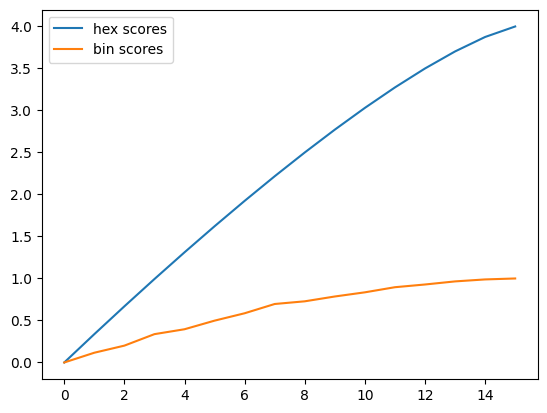

In [50]:
def main():
    hex_host_ids = [
        "0000000000000001", # least random looking
        "0000000000001234", # least random looking
        "0101010101010101", # location
        ''.join(sorted(list("0101010101010101"))), # same as above but sorted
        "00000000000021f5", # irl example
        "0193025300770135", # irl example of extended v4 address
        "cec7cb3dce4f938f", # made by PRNG
        "f9198bc53b127e76", # made by PRNG
        ''.join(sorted(list("f9198bc53b127e76"))), # same as above but sorted
        "0123456789abcdef", # manual string hitting all hex numbers
        "0468ac7db32e9f15", # same as above but in different order
    ]
    for hid in hex_host_ids: 
        print(f"{hid:>16} --> {shannon_bin(hid):>20} binary")
        print(f"{" "*len(hid):>16} --> {shannon_hex(hid):>20} hex")
    
    plot()

if __name__ == "__main__":
    main()